# IQR (INTER QUARTILE METHOD)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("DataSets/employee_salaries.csv")
df.head()

,employee_id,department,salary_in_k
0,E001,IT,60
1,E002,HR,55
2,E003,Finance,70
3,E004,IT,65
4,E005,Marketing,50


In [3]:
df.describe()

,salary_in_k
count,205.000000
mean,61.843902
std,11.990397
min,5.000000
25%,56.000000
50%,61.000000
75%,67.000000
max,150.000000


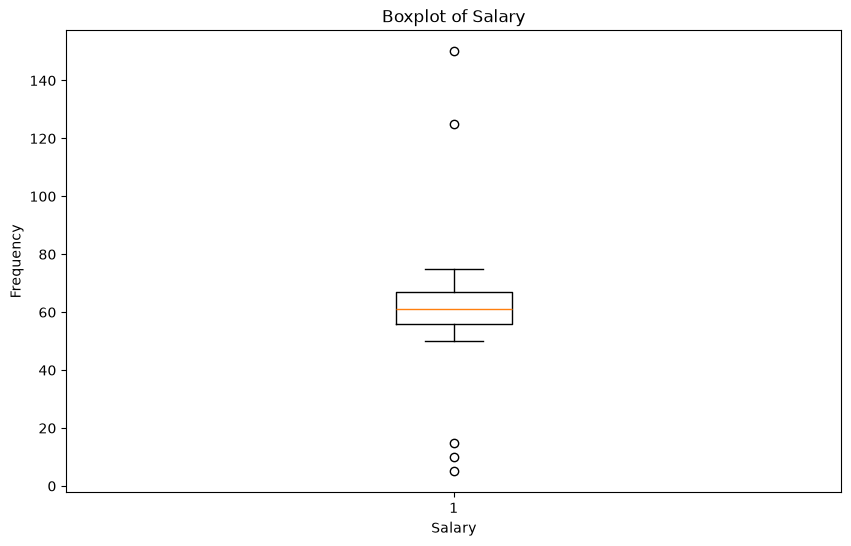

In [4]:
plt.figure(figsize=(10,6))
plt.boxplot(df['salary_in_k'])
plt.title('Boxplot of Salary')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

In [5]:
Q1 = df['salary_in_k'].quantile(0.25)
Q3 = df['salary_in_k'].quantile(0.75)
IQR = Q3 - Q1
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 56.0
Q3: 67.0
IQR: 11.0


In [6]:
lower_limit=Q1 - 1.5 * IQR
upper_limit=Q3 + 1.5 * IQR
print("Lower Limit:", lower_limit)
print("upper_limit:", upper_limit)

Lower Limit: 39.5
upper_limit: 83.5


In [7]:
#Display Outliers
outlier=df[(df['salary_in_k'] < lower_limit) | (df['salary_in_k'] > upper_limit)]
print("Outliers:\n", outlier)

Outliers:
     employee_id department  salary_in_k
200        E201         IT           15
201        E202    Finance          125
202        E203         IT           10
203        E204  Marketing            5
204        E205         HR          150


In [8]:
df_cleaned = df[(df['salary_in_k'] >= lower_limit) & (df['salary_in_k'] <= upper_limit)]
df_cleaned


,employee_id,department,salary_in_k
0,E001,IT,60
1,E002,HR,55
2,E003,Finance,70
3,E004,IT,65
4,E005,Marketing,50
...,...,...,...
195,E196,IT,64
196,E197,HR,59
197,E198,Finance,72
198,E199,Marketing,54


In [9]:
df_cleaned.shape, df.shape

((200, 3), (205, 3))

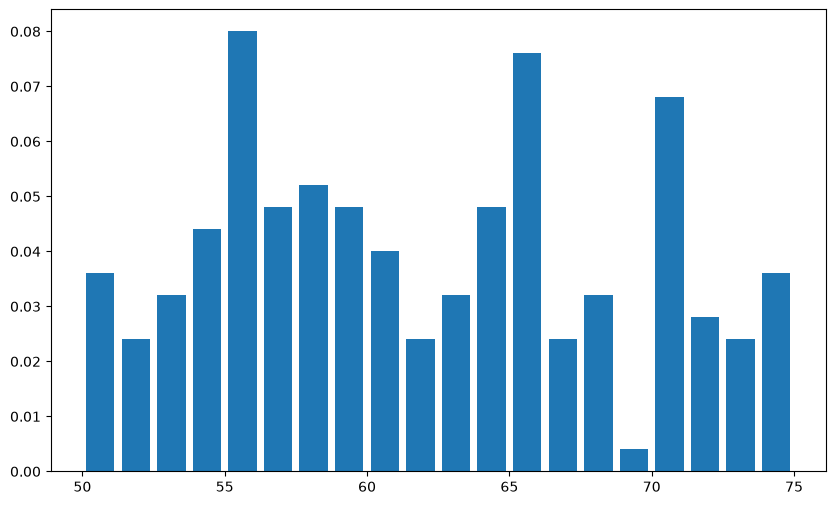

In [10]:
plt.figure(figsize=(10,6))
plt.hist(df_cleaned['salary_in_k'], bins=20,rwidth=0.8, density=True)
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x2d8d3c563c0>,
 'caps': [<matplotlib.lines.Line2D at 0x2d8d3c56120>,
 'boxes': [<matplotlib.lines.Line2D at 0x2d8d3c55d30>],
 'medians': [<matplotlib.lines.Line2D at 0x2d8d3c56660>],
 'fliers': [<matplotlib.lines.Line2D at 0x2d8d3c56510>],
 'means': []}

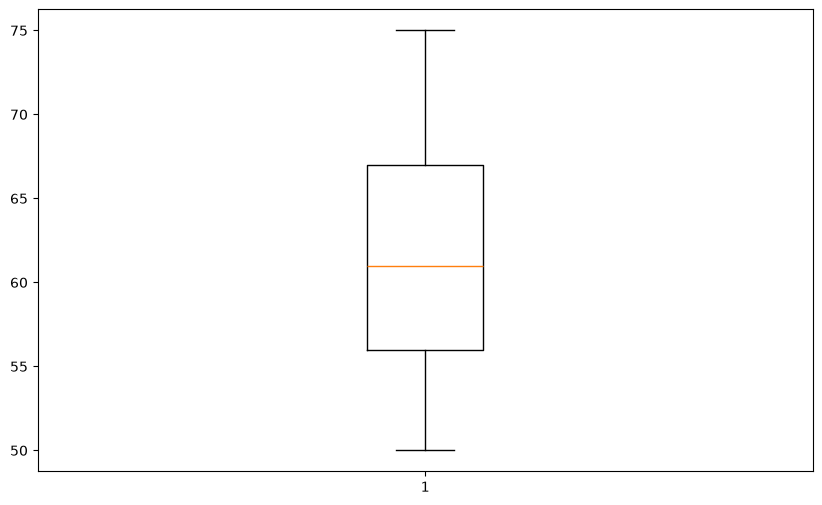

In [11]:
plt.figure(figsize=(10,6))
plt.boxplot(df_cleaned['salary_in_k'])

Exercise

Exercise: Outlier Detection and Removal using Quantile, Standard Deviation, Z-score and IQR Methods


Problem Statement: Outlier Detection and Removal using various methods


You have been provided with a dataset `customer_profile.csv` containing features such as `Age`, `Income`, and `Spending_Score`.


Your task is to identify and remove outliers from these features using multiple data cleaning methods.


Tasks to be Performed:


1.  Quantile Method: Remove the most extreme outliers using the `[0.001, 0.999]` percentile range on the `Income` feature.
2.  Standard Deviation Method: Apply the Standard Deviation method with a threshold of 3 on the `Spending_Score` feature.
3.  Z-Score Method (Manual): Calculate Z-scores manually and use a threshold of `|Z| > 3` to remove outliers from the `Age` feature.
4.  Interquartile Range (IQR) Method: Use the IQR method to identify and remove outliers from the `Income` feature.
5.  Visualize and Compare: Use plots to visualize the data distribution before and after each method to understand the effect of outlier removal.

In [12]:
df=pd.read_csv("DataSets/customer_profile.csv")
df.head()

,Age,Income,Spending_Score
0,39.967142,63892.66321,77.987109
1,33.617357,78641.24961,68.492674
2,41.476885,29021.48639,51.192607
3,50.230299,58444.53855,37.061264
4,32.658466,40240.36146,63.964466


In [13]:
df.describe()

,Age,Income,Spending_Score
count,504.000000,504.000000,504.000000
mean,35.047996,51376.380710,52.588979
std,10.264667,20605.775549,22.554853
min,-10.000000,5000.000000,-7.925108
25%,27.965428,41070.623905,37.887192
50%,35.127971,50438.757215,52.396117
75%,41.367833,59939.196162,65.179705
max,85.000000,300000.000000,250.000000


In [14]:
#Quantile Method: Remove the most extreme outliers using the 
# `[0.001, 0.999]` percentile range on the `Income` feature.
upper_limit = df['Income'].quantile(0.999)
lower_limit = df['Income'].quantile(0.001)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: 7286.990279068
Upper Limit: 274850.0000000007


In [15]:
outlier=df[(df['Income'] <= lower_limit) | (df['Income'] >= upper_limit)]
print("Outliers:\n", outlier)

Outliers:
       Age    Income  Spending_Score
501  15.0    5000.0           150.0
503 -10.0  300000.0            10.0


In [16]:
df_cleaned_Quantile = df[(df['Income'] >= lower_limit) & (df['Income'] <= upper_limit)]
print("Cleaned DataFrame (Quantile Method):\n", df_cleaned_Quantile)


Cleaned DataFrame (Quantile Method):
            Age        Income  Spending_Score
0    39.967142   63892.66321       77.987109
1    33.617357   78641.24961       68.492674
2    41.476885   29021.48639       51.192607
3    50.230299   58444.53855       37.061264
4    32.658466   40240.36146       63.964466
..         ...           ...             ...
497  33.096613   59612.64292       74.167325
498  26.243817   41432.31515       70.481251
499  21.172003   58588.74172       61.850539
500  85.000000  250000.00000       10.000000
502  40.000000  100000.00000      250.000000

[502 rows x 3 columns]


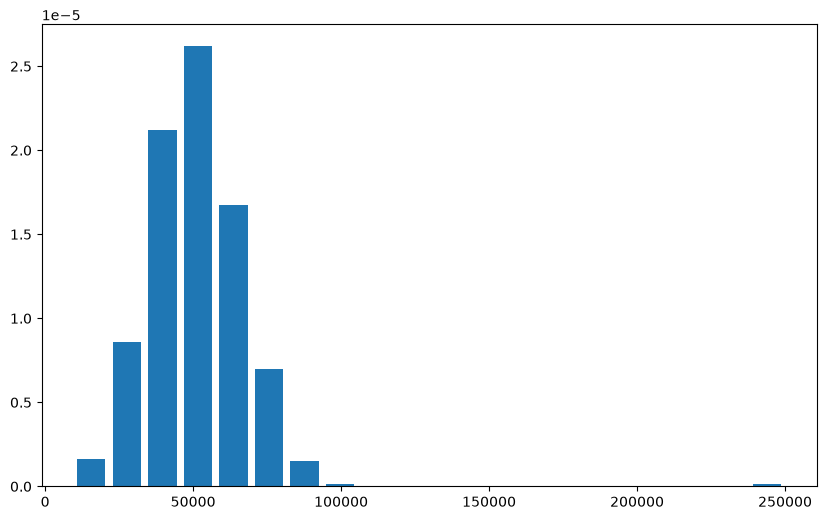

In [17]:
plt.figure(figsize=(10,6))
plt.hist(df_cleaned_Quantile['Income'], bins=20,rwidth=0.8, density=True)
plt.show()

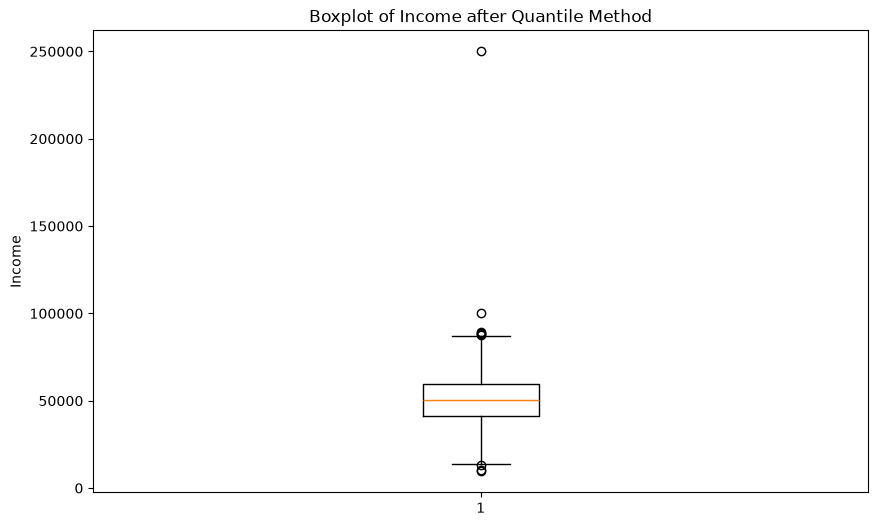

In [18]:
plt.figure(figsize=(10,6))
plt.boxplot(df_cleaned_Quantile['Income'])
plt.ylabel('Income')
plt.title('Boxplot of Income after Quantile Method')
plt.show()

In [19]:
#Standard Deviation Method: Apply the Standard Deviation method with 
# a threshold of 3 on the `Spending_Score` feature.
df_std=df_cleaned_Quantile.copy()
df_std

,Age,Income,Spending_Score
0,39.967142,63892.66321,77.987109
1,33.617357,78641.24961,68.492674
2,41.476885,29021.48639,51.192607
3,50.230299,58444.53855,37.061264
4,32.658466,40240.36146,63.964466
...,...,...,...
497,33.096613,59612.64292,74.167325
498,26.243817,41432.31515,70.481251
499,21.172003,58588.74172,61.850539
500,85.000000,250000.00000,10.000000


In [20]:


mean = df_std["Spending_Score"].mean()
std = df_std["Spending_Score"].std()

lower = mean - 3*std
upper = mean + 3*std

df_std = df_std[
    (df_std["Spending_Score"] >= lower) &
    (df_std["Spending_Score"] <= upper)
]

print("Original Shape:", df.shape)
print("After Standard Deviation:", df_std.shape)

Original Shape: (504, 3)
After Standard Deviation: (501, 3)


Visualize Before and After (Standard Deviation)

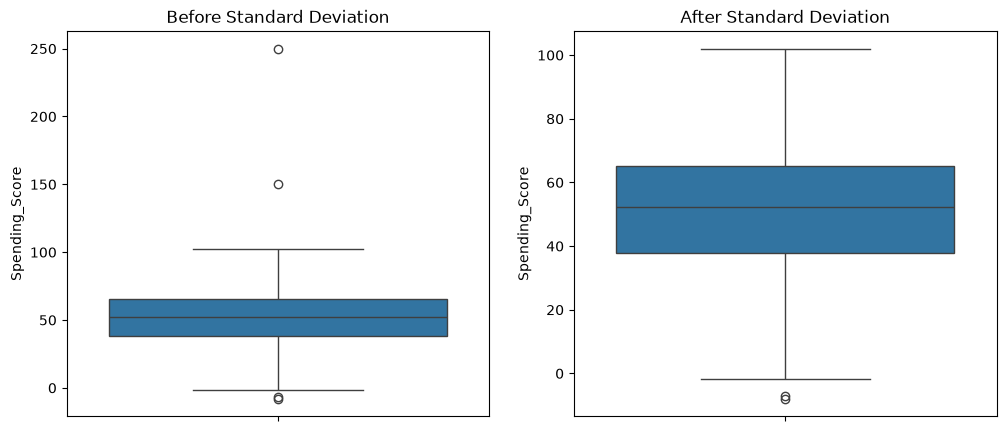

In [21]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["Spending_Score"])
plt.title("Before Standard Deviation")

plt.subplot(1,2,2)
sns.boxplot(y=df_std["Spending_Score"])
plt.title("After Standard Deviation")

plt.show()

Z-Score Method (Manual) on Age

In [22]:
df_z = df.copy()

mean = df_z["Age"].mean()
std = df_z["Age"].std()

# Manual Z-score calculation
z_score = (df_z["Age"] - mean) / std

# Remove outliers
df_z = df_z[np.abs(z_score) <= 3]

print("Original Shape:", df.shape)
print("After Z-Score Method:", df_z.shape)

Original Shape: (504, 3)
After Z-Score Method: (500, 3)


Visualize Before and After (Z-Score)

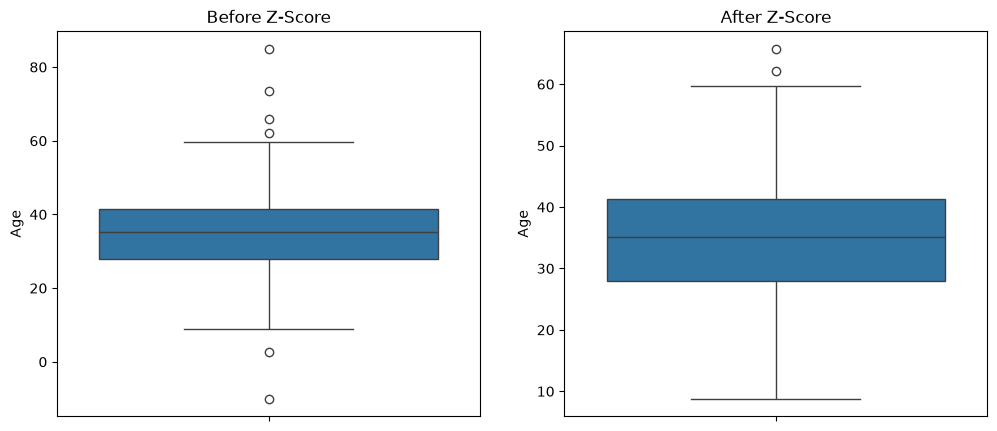

In [23]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["Age"])
plt.title("Before Z-Score")

plt.subplot(1,2,2)
sns.boxplot(y=df_z["Age"])
plt.title("After Z-Score")

plt.show()

IQR Method (Income Feature)

In [24]:
df_iqr = df.copy()

Q1 = df_iqr["Income"].quantile(0.25)
Q3 = df_iqr["Income"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_iqr = df_iqr[
    (df_iqr["Income"] >= lower) &
    (df_iqr["Income"] <= upper)
]

print("Original Shape:", df.shape)
print("After IQR Method:", df_iqr.shape)

Original Shape: (504, 3)
After IQR Method: (495, 3)


Visualize Before and After (IQR)

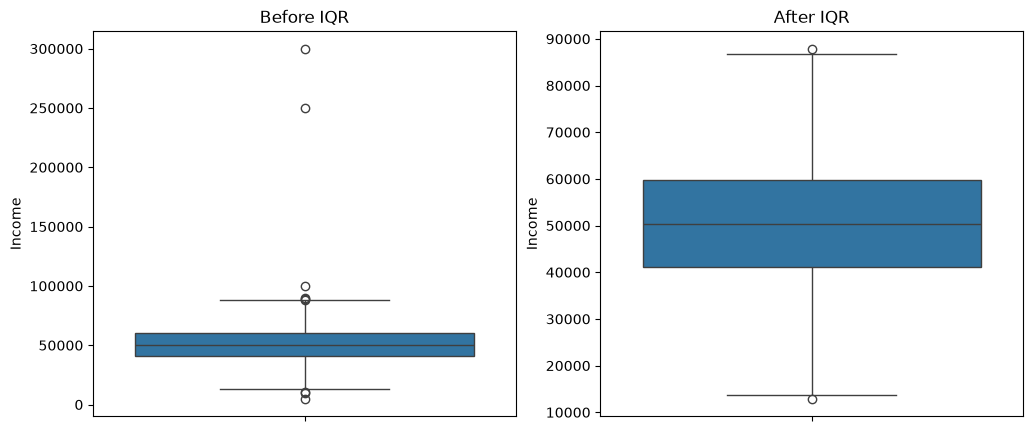

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["Income"])
plt.title("Before IQR")

plt.subplot(1,2,2)
sns.boxplot(y=df_iqr["Income"])
plt.title("After IQR")

plt.show()

Compare Distributions Before and After

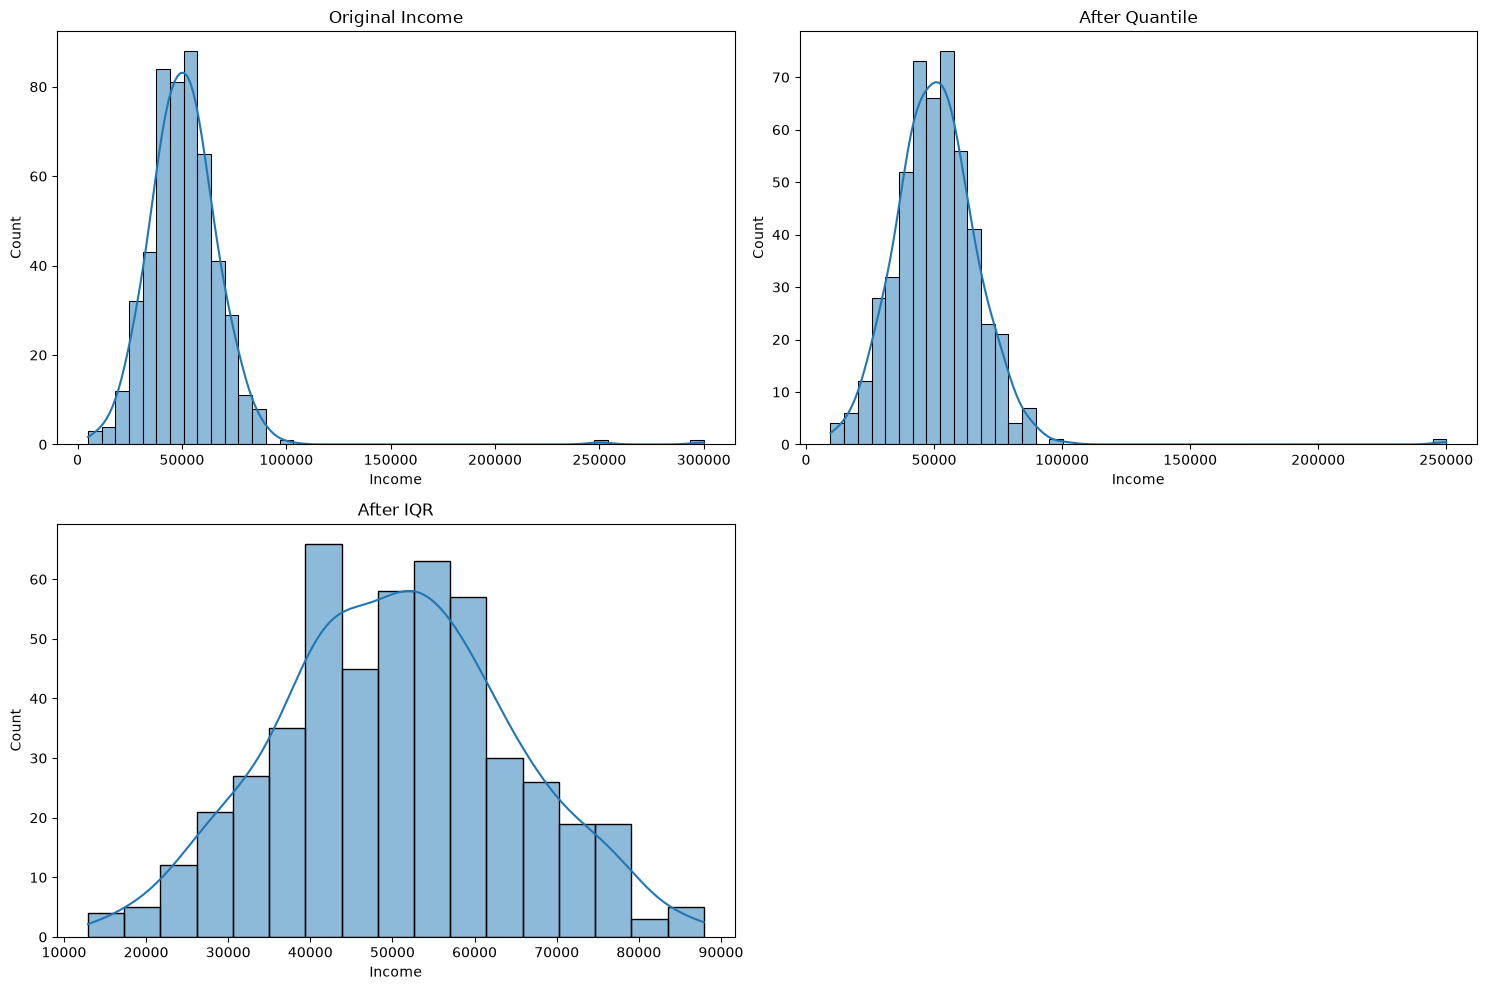

In [28]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
sns.histplot(df["Income"], kde=True)
plt.title("Original Income")

plt.subplot(2,2,2)
sns.histplot(df_cleaned_Quantile["Income"], kde=True)
plt.title("After Quantile")

plt.subplot(2,2,3)
sns.histplot(df_iqr["Income"], kde=True)
plt.title("After IQR")

plt.tight_layout()
plt.show()

Compare Age Distribution

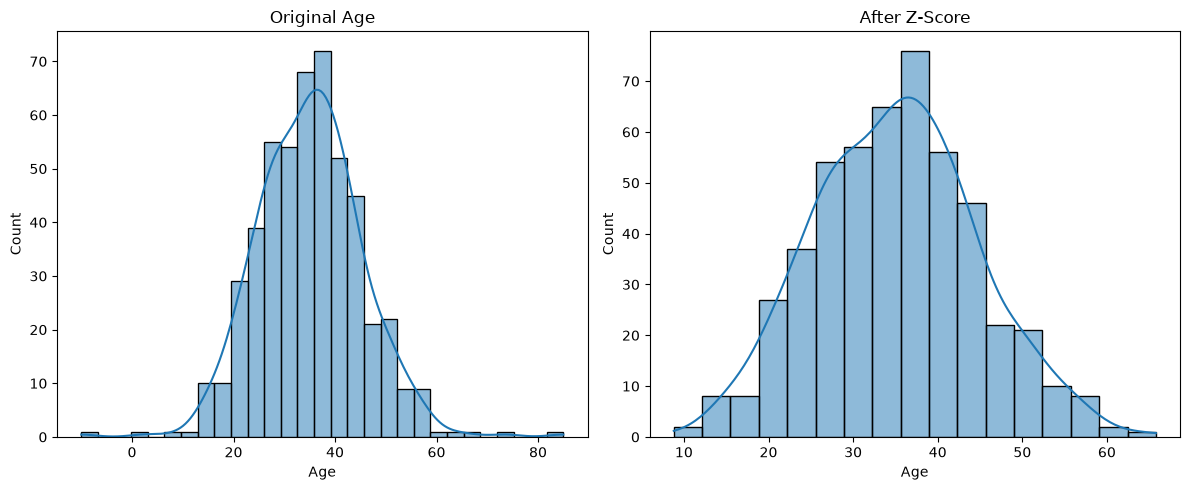

In [29]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["Age"], kde=True)
plt.title("Original Age")

plt.subplot(1,2,2)
sns.histplot(df_z["Age"], kde=True)
plt.title("After Z-Score")

plt.tight_layout()
plt.show()

Compare Spending Score Distribution

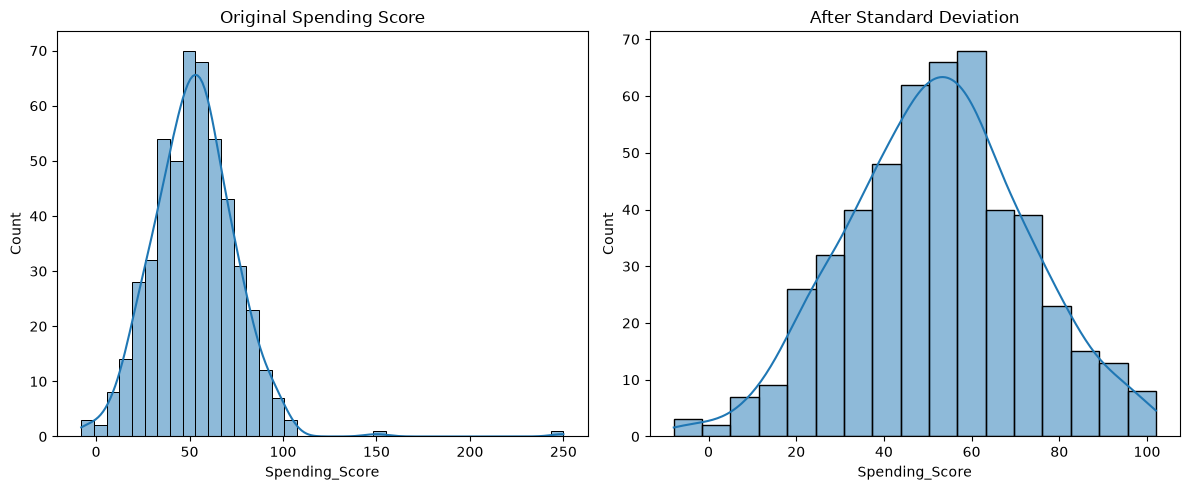

In [30]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["Spending_Score"], kde=True)
plt.title("Original Spending Score")

plt.subplot(1,2,2)
sns.histplot(df_std["Spending_Score"], kde=True)
plt.title("After Standard Deviation")

plt.tight_layout()
plt.show()